In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df = pd.read_csv("Clean_Cafe_sales_without_unusable.csv")
plt.style.use('seaborn-v0_8-whitegrid')

### What should the cafe prioritise to grow revenue in 2024

In [5]:
df = df[['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date']]
df.dtypes
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

##### Which items drive the most revenue vs. the most transactions — are they the same?  

In [6]:
items_grp = df.groupby(['Item'])
item_revenue_stats = items_grp.agg(
    Unit_price = ('Price Per Unit', 'first'),
    Revenue = ('Total Spent', 'sum')
).sort_values(by='Revenue', ascending=False)
item_revenue_stats['Rolling_total'] = item_revenue_stats['Revenue'].cumsum()
item_revenue_stats['Percentage_of_total_Revenue'] = (item_revenue_stats['Rolling_total']/item_revenue_stats['Rolling_total'].max())*100

In [7]:
item_revenue_stats

,Unit_price,Revenue,Rolling_total,Percentage_of_total_Revenue
Item,,,,
Salad,5.0,19095.0,19095.0,21.444936
Sandwich,4.0,16532.0,35627.0,40.011455
Smoothie,4.0,13344.0,48971.0,54.997642
Juice,3.0,12786.0,61757.0,69.357157
Cake,3.0,10404.0,72161.0,81.041531
Coffee,2.0,7808.0,79969.0,89.810427
Tea,1.5,5475.0,85444.0,95.959210
Cookie,1.0,3598.0,89042.0,100.000000


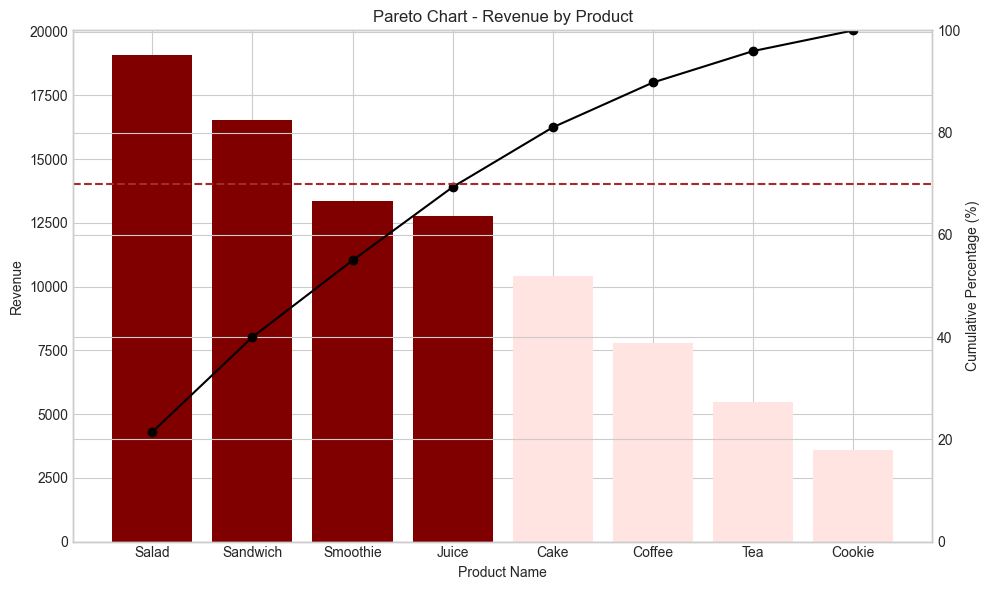

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))
colors = [
    'maroon' if pct <= 70 else 'mistyrose'
    for pct in item_revenue_stats['Percentage_of_total_Revenue']
]
ax1.bar(
    item_revenue_stats.index,
    item_revenue_stats['Revenue'],
    color=colors
)
ax1.set_xlabel('Product Name')
ax1.set_ylabel('Revenue')
ax1.set_title('Pareto Chart - Revenue by Product')

ax2 = ax1.twinx()
ax2.plot(
    item_revenue_stats.index,
    item_revenue_stats['Percentage_of_total_Revenue'],
    marker='o',
    c='black'
)
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 100)
ax2.axhline(70, linestyle='--', color='brown')
plt.tight_layout()
plt.show()

- Evidence 
    - Products with higher Price Per Unit generate higher Revenue
    - Top 4 products generate almost 70% of the Revenue
        - Top 2 alone generate 40% of the Revenue

In [9]:
item_transaction_stats = items_grp.agg(
    Unit_price = ('Price Per Unit', 'first'),
    Transaction_count = ('Transaction ID', 'count'),
    avg_quantity_per_transaction = ('Quantity', 'mean')
).sort_values(by='Transaction_count', ascending=False)
item_transaction_stats

,Unit_price,Transaction_count,avg_quantity_per_transaction
Item,,,
Juice,3.0,1415,3.012014
Sandwich,4.0,1354,3.052437
Coffee,2.0,1286,3.035770
Salad,5.0,1270,3.007087
Cookie,1.0,1211,2.971098
Tea,1.5,1206,3.026534
Cake,3.0,1138,3.047452
Smoothie,4.0,1094,3.049360


- evidence: 
    - Products with most transactions are not the ones generating the most revenue.
    - average quantity per transaction is almost 3 for all the items 
    

- Detailed Breakdown:
    - Item generating most Revenue (Salad) has only 59 more transactions than and the Item generating the least Revenue (Cookie).
    - One affecting factor could've been Quantity per transaction (Which can possibly contribute to more Revenue in items with less transaction).
        - However, avg quantity per transaction is near 3 for all items. Hence, this factors contribution is not significant for the Items with higher Revenue.
    - Item generating the 3rd most Revenue has the least transactions
        - Suggests that the factor Revenue By Item relies massively on is Price Per Unit.

##### Are there items that sell well in volume but contribute little to revenue?  

In [10]:
item_combined_stats = pd.concat([
    item_transaction_stats['Transaction_count'],
    item_revenue_stats['Revenue']
], axis='columns')

item_combined_stats['Revenue_Rank'] = (
    item_combined_stats['Revenue']
    .rank(method='dense', ascending=False)
    .astype(int)
)

def percentage_of_total(df, col):
    col_name = col+'_contribution%'
    df[col_name] = (df[col]/np.sum(df[col]))*100
    return df
percentage_of_total(item_combined_stats,'Revenue')
item_combined_stats.sort_values(by='Transaction_count',ascending=False)

,Transaction_count,Revenue,Revenue_Rank,Revenue_contribution%
Item,,,,
Juice,1415,12786.0,4,14.359516
Sandwich,1354,16532.0,2,18.566519
Coffee,1286,7808.0,6,8.768896
Salad,1270,19095.0,1,21.444936
Cookie,1211,3598.0,8,4.040790
Tea,1206,5475.0,7,6.148784
Cake,1138,10404.0,5,11.684374
Smoothie,1094,13344.0,3,14.986186


- Evidence: 
    - Coffee has 3rd most transaction count but ranks 6th for Revenue generation (contributes only 8.7% of the Revenue)
    - Cookie has 5th most transactions but contributes only 4.04% of the Revenue
    - Similar for Tea, 6th most transactions but Revenue contribution is 6.15%

- Action in 2024:
    - Price revision for products like: Coffee and Cookie.
    - Product Strategies:
        - Introduce serving sizes in Coffees with different Price.
        - Introduce Flavours in Cookies with different Price.

##### Does purchasing behaviour differ between In-store and Takeaway customers?  

In [11]:
location_df = df[df['Location'] != 'Unavailable']
location_grp = location_df.groupby('Location')
location_grp['Item'].value_counts(normalize=True)*100

Location  Item    
In-Store  Juice       14.637392
          Sandwich    14.271457
          Salad       13.439787
          Cookie      12.341983
          Tea         12.242182
          Coffee      11.709914
          Cake        10.678643
          Smoothie    10.678643
Takeaway  Juice       13.759947
          Sandwich    13.660477
          Cookie      13.328912
          Coffee      13.096817
          Salad       12.533156
          Tea         12.201592
          Cake        11.372679
          Smoothie    10.046419
Name: proportion, dtype: float64

- Evidence:
    - Top (Juice, Sandwich) and Bottom (Cake, Smoothie) 2 Items are same across both locations.(In transactions)

In [12]:
pd.crosstab(location_df['Item'], location_df['Location'], normalize=True)*100

Location,In-Store,Takeaway
Item,,
Cake,5.330455,5.695782
Coffee,5.845234,6.559283
Cookie,6.160744,6.675523
Juice,7.306543,6.891398
Salad,6.708735,6.276984
Sandwich,7.123879,6.841581
Smoothie,5.330455,5.031551
Tea,6.110927,6.110927


- Evidence:
    - Coffee lead by a thin margin in Takeaway orders (0.7% more) 
    - The rest have similar orders for both Locations (around 0.5% difference)

In [13]:
location_stats = location_grp.agg(
    transaction_count = ('Transaction ID','count'),
    Revenue = ('Total Spent', 'sum'),
    avg_spent_per_transaction = ('Total Spent', 'mean')
)
location_stats['Rev_contribution'] = (location_stats['Revenue']/location_stats['Revenue'].sum())*100
location_stats

,transaction_count,Revenue,avg_spent_per_transaction,Rev_contribution
Location,,,,
In-Store,3006,27140.0,9.028609,50.547097
Takeaway,3016,26552.5,8.803879,49.452903


- Evidence:
    - Both Takeaway and In-Store have similar transactions, and contribute almost 50,50% to the revenue

In [14]:
location_item_grp = location_df.groupby(['Location','Item'])
location_item_grp['Quantity'].mean()

Location  Item    
In-Store  Cake        3.087227
          Coffee      3.062500
          Cookie      2.938005
          Juice       3.077273
          Salad       3.037129
          Sandwich    3.034965
          Smoothie    2.968847
          Tea         3.086957
Takeaway  Cake        3.055394
          Coffee      3.075949
          Cookie      3.032338
          Juice       2.985542
          Salad       2.944444
          Sandwich    3.114078
          Smoothie    3.042904
          Tea         3.002717
Name: Quantity, dtype: float64

- Evidence:
    - Product Quantity for each item remains near 3 for both locations

In [15]:
location_grp['Payment Method'].value_counts(normalize=True)*100

Location  Payment Method
In-Store  Unavailable       31.104458
          Cash              23.286760
          Digital Wallet    23.020625
          Credit Card       22.588157
Takeaway  Unavailable       31.266578
          Digital Wallet    24.568966
          Credit Card       22.181698
          Cash              21.982759
Name: proportion, dtype: float64

- Payment method values have a lot of rows as 'Unavailable' weakening the analysis
- Evidence: 
    - Customers for Takeaway prefer to pay via Digital Wallet and secondly by Credit Card.
    - Customers In-Store prefer to pay with cash(Slightly)


- Detailed Breakdown
    - There doesn't seem to be a major difference in customer purchase behaviour for In-Store and Takeaway
    - The only differences seen are:
        - Coffee is ordered 0.7% more in takeaway orders.
            - noise probably
        - payment method, even there the data is not sufficient to state that as true difference
            - 31% data for both Locations is Unavailable

- Action in 2024:
    - Promotion strategies:
        1. If further data confirms a Coffee preference in Takeaway orders, a Digital Wallet promotion could be worth testing
            - Discount on Digital Wallet payment.
            - Promotion of quick drive through service
                - Coffee within 3 minutes 

##### Is there a day-of-week or monthly pattern in sales volume or revenue?  

In [16]:
month_grp = df.groupby(df['Transaction Date'].dt.month)
monthly_stats = month_grp.agg(
    monthly_revenue = ('Total Spent','sum'),
    total_transactions = ('Transaction ID', 'count')
).sort_index()

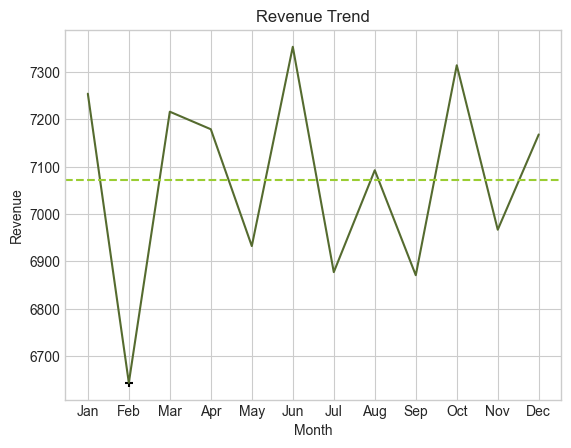

In [17]:
plt.plot(
    monthly_stats.index,
    monthly_stats['monthly_revenue'],
    color='darkolivegreen')
plt.scatter(
    2,
    monthly_stats['monthly_revenue'].min(),
    color='k', 
    marker='+')
plt.axhline(
    monthly_stats['monthly_revenue'].mean(), 
    color='yellowgreen', 
    linestyle='--')
plt.xticks(
    monthly_stats.index, 
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue Trend')
plt.show()

In [18]:
Q1 = monthly_stats['monthly_revenue'].quantile(0.25)
Q3 = monthly_stats['monthly_revenue'].quantile(0.75)
IQR = Q3 - Q1
assert not ((monthly_stats['monthly_revenue'] < Q1 - 1.5*IQR) | (monthly_stats['monthly_revenue'] > Q3 + 1.5*IQR)).any()

- Evidence:
    - Monthly Revenue trend hovers around the mean, only noticeable discrepancy:
        - February shows a dip in revenue, going below 6700 in revenue
            - However, it is still within IQR

In [19]:
mask = df['Transaction Date'].dt.month == 2
feb_week_grp = df[mask].groupby((df['Transaction Date'].dt.day-1)//7+1)
feb_week_grp['Total Spent'].sum().sort_values(ascending=False)

Transaction Date
3.0    1808.5
4.0    1663.0
1.0    1638.5
2.0    1534.0
Name: Total Spent, dtype: float64

In [20]:
def Revenue_by_week(month_no,df):
    mask = df['Transaction Date'].dt.month == month_no
    return df[mask].groupby((df['Transaction Date'].dt.day-1)//7+1)['Total Spent'].sum().sort_values(ascending=False)

In [21]:
Revenue_by_week(5,df)
Revenue_by_week(7,df)
Revenue_by_week(9,df)
Revenue_by_week(6,df)
Revenue_by_week(1,df)
Revenue_by_week(11,df)

Transaction Date
4.0    1701.0
3.0    1668.0
2.0    1604.0
1.0    1561.5
5.0     432.5
Name: Total Spent, dtype: float64

In [22]:
month_grp['Quantity'].mean()

Transaction Date
1.0     3.003681
2.0     3.103306
3.0     2.990315
4.0     3.077821
5.0     3.020725
6.0     3.012240
7.0     2.961977
8.0     3.008739
9.0     3.000000
10.0    3.033453
11.0    2.987245
12.0    3.064557
Name: Quantity, dtype: float64

- Evidence: 
    - All months have 5 weeks(last week of 2-3 days) except february
        - 5th week generates almost 400-600 for every month.
    - Quantity per transaction for every month is similar (around 3)

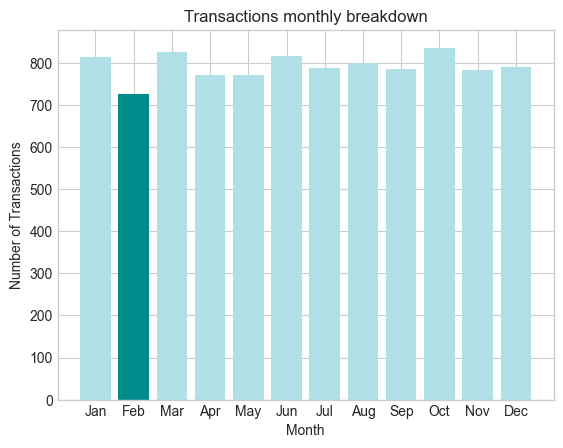

In [23]:
colors = [
    'darkcyan' if bar == monthly_stats['total_transactions'].min() else 'powderblue'
    for bar in monthly_stats['total_transactions']
]
plt.bar(
    monthly_stats.index, 
    monthly_stats['total_transactions'], 
    color=colors)
plt.xticks(
    monthly_stats.index,
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Transactions monthly breakdown')
plt.show()

- Evidence:
    - All months have similar Transaction count, except february

- Detailed Breakdown:
    - By comparing February and other months Revenue by week, it is safe to say the Revenue dip is due to the missing last week (Feb only has 28 days).
        - Can be stated because Quantity sold per transaction for every month is almost the same
    - February has a minor dip in transaction count as well, safe to say due to lesser days in the month.

In [24]:
day_grp = df.groupby(df['Transaction Date'].dt.weekday)
day_stats = day_grp.agg(
    Revenue = ('Total Spent','sum'),
    total_transactions = ('Transaction ID', 'count'),
).sort_index()
day_stats['Rev_rank'] = day_stats['Revenue'].rank(method='dense',ascending=False).astype(int)

In [25]:
day_stats.sort_values(by='total_transactions', ascending=False)

,Revenue,total_transactions,Rev_rank
Transaction Date,,,
4.0,12334.0,1383,2
0.0,12140.0,1379,4
6.0,12287.5,1378,3
3.0,12401.5,1376,1
5.0,11994.5,1352,6
2.0,11671.5,1338,7
1.0,12039.5,1308,5


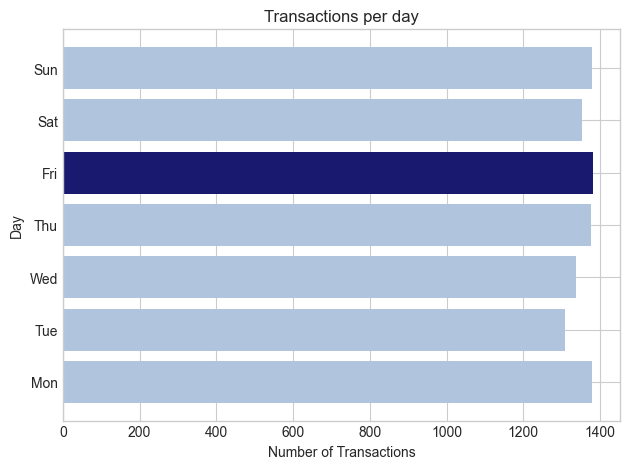

In [26]:
colors = [
    'midnightblue' if bar == day_stats['total_transactions'].max() else 'lightsteelblue'
    for bar in day_stats['total_transactions']
]
plt.barh(
    day_stats.index, 
    day_stats['total_transactions'],
    color=colors)
plt.yticks(
    day_stats.index, 
    ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.ylabel('Day')
plt.xlabel('Number of Transactions')
plt.title('Transactions per day')
plt.tight_layout()
plt.show()

- Evidence: 
    - The number of transactions are consistent throughout the week around 1350, except for tuesday(number of transactions = 1308)
        - However, ranks 5th for revenue
- Breakdown:
    - tuesday decline in orders is not a significant drop thus, no further analysis

##### Which payment method is associated with higher average spend?  

In [27]:
pay_method_df = df[df['Payment Method'] != 'Unavailable']
pay_method_grp = pay_method_df.groupby('Payment Method')
pay_method_grp.agg(
    Revenue = ('Total Spent','sum'),
    avg_spent = ('Total Spent','mean'),
    avg_quantity = ('Quantity','mean'),
    total_transactions = ('Transaction ID','count')
).sort_values(by='avg_spent', ascending=False)


,Revenue,avg_spent,avg_quantity,total_transactions
Payment Method,,,,
Cash,20402.5,9.051686,3.035049,2254
Credit Card,20446.0,9.014991,3.018519,2268
Digital Wallet,20405.0,8.933888,3.035464,2284


- Evidence:
    - Average Spent, Average Quantity, and Transactions count are all similar around 9, 3, 2065 respectively

In [28]:
pay_method_df.groupby(['Payment Method','Item'])['Total Spent'].agg(
    ['sum','mean']).sort_values('mean',ascending=False)

sum       mean
Payment Method Item                       
Digital Wallet Salad     4235.0  15.456204
Credit Card    Salad     4595.0  15.016340
Cash           Salad     4715.0  14.920886
               Smoothie  2984.0  12.697872
Digital Wallet Sandwich  3860.0  12.451613
Cash           Sandwich  3660.0  12.364865
Digital Wallet Smoothie  3108.0  12.236220
Credit Card    Smoothie  3076.0  12.206349
               Sandwich  3828.0  12.000000
               Cake      2385.0   9.464286
Digital Wallet Cake      2280.0   9.268293
Cash           Cake      2517.0   9.119565
Digital Wallet Juice     3060.0   9.026549
Credit Card    Juice     2904.0   8.935385
Cash           Juice     2871.0   8.753049
               Coffee    1638.0   6.181132
Digital Wallet Coffee    1758.0   6.000000
Credit Card    Coffee    1622.0   5.898182
               Tea       1227.0   4.701149
Digital Wallet Tea       1257.0   4.521583
Cash           Tea       1186.5   4.494318
               Cookie     831.0   3.032847
Digital Wallet Cookie     847.0   2.920690
Credit Card    Cookie     809.0   2.910072

- Evidence: 
    - Average spent on an Item does not vary with Payment Method, only exceptions are Sandwich purchased on Credit Card and Smoothie purchased on Cash.
        - Difference in mean for exceptions is around 0.4

- Detailed Breakdown:
    - Average spent is the same across all Payment Methods
    - Exceptions in Average spent on an Item by Payment Method are insignificant.
        - Can be described as:
            - Single/ few Customers who frequently purchases the same Item by the same Payment Method.
    - However, no customer details available to verify this assumption. Hence, the conclusion: 
        - No change in Average spent due to Payment Method

##### Conclusion - What should the cafe prioritise to grow revenue in 2024?

The analysis points to one clear lever: **pricing strategy on high-volume, 
low-price items.**

Revenue across the cafe's 8 products is almost entirely determined by 
Price Per Unit, not by how many transactions an item generates or how 
much quantity is sold per visit. The top 4 items (Salad, Smoothie, 
Sandwich, Juice) contribute 70% of total revenue simply because they 
cost more. Coffee, Cookie, and Tea collectively account for ~19% of 
revenue despite driving a significant share of foot traffic. The cafe 
is undermonetising its most popular items.

**Priority actions:**
1. Introduce tiered pricing on Coffee (small/medium/large). 
   Anchoring the small size at the current price reduces perceived 
   price increase while lifting average transaction value.
2. Introduce premium Cookie variants (flavours, sizes) to create a 
   higher price point without replacing the existing product.
3. Bundle high-margin items with popular low-price ones to lift basket value 
   while softening the effect of price changes on the customer.

**What the data ruled out:**
- Location is not a priority lever. In-store and Takeaway split 
  revenue almost exactly 50/50 with identical product preferences,
  channel-specific strategies are unlikely to move the needle.
- Day-of-week and monthly patterns do not exist. 2023 revenue 
  was flat with no seasonality beyond February's dip, which is 
  fully explained by the shorter month.
- Payment method has no effect on spend. No payment-based 
  promotion would change revenue.

**Data limitations to note:**
- 40% of Location and 32% of Payment Method values were 
  unrecoverable, which limits confidence in channel-level findings.
- No customer IDs exist in the dataset, so it is unknown whether 
  high transaction counts reflect loyal regulars or broad reach,
  this matters for how aggressively pricing should be changed.
